# Proyecto Calidad del Agua 

# Introducción

El acceso a agua potable es un derecho humano fundamental y un factor determinante para la salud pública. A pesar de los avances globales en saneamiento, millones de personas aún consumen agua que no cumple estándares mínimos de potabilidad, lo que representa un riesgo directo para su salud.

En este proyecto se aborda la predicción de la potabilidad del agua mediante técnicas de machine learning aplicadas sobre el dataset **Water Potability**, que contiene 3.276 muestras con nueve variables fisicoquímicas: pH, dureza, sólidos disueltos, cloraminas, sulfatos, conductividad, carbono orgánico, trihalometanos y turbidez. La variable objetivo indica si el agua es potable (`1`) o no potable (`0`).

El enfoque adoptado cubre el ciclo completo de un proyecto de clasificación: análisis exploratorio, preprocesamiento dentro de un pipeline exportable, comparación de tres modelos de clasificación (Regresión Logística, Árbol de Decisión y Random Forest), optimización de hiperparámetros con validación cruzada, ajuste del umbral de decisión y exportación del modelo para su uso futuro en aplicaciones externas como Streamlit.

# Objetivos

**Objetivo general**

Desarrollar y exportar un modelo de machine learning capaz de predecir la potabilidad del agua a partir de sus parámetros fisicoquímicos, siguiendo un pipeline reproducible y listo para su integración en aplicaciones externas.

**Objetivos específicos**

* Realizar un análisis exploratorio de los datos para comprender la distribución de las variables, detectar valores faltantes, outliers y el desbalance de clases.

* Construir un pipeline unificado que encadene imputación de valores faltantes, estandarización y balanceo de clases, garantizando que el preprocesamiento sea reproducible y no genere fuga de información entre entrenamiento y prueba.

* Comparar tres modelos de clasificación — Regresión Logística, Árbol de Decisión y Random Forest — utilizando métricas de accuracy, precision, recall, F1-score y ROC-AUC.

* Optimizar los hiperparámetros del mejor modelo mediante GridSearchCV con validación cruzada de cinco pliegues.

* Ajustar el umbral de decisión para mejorar el balance entre precision y recall según las necesidades del problema.

* Identificar las variables fisicoquímicas más influyentes en la predicción mediante análisis de importancia de características.

* Exportar el modelo final como un archivo `.pkl` autocontenido, capaz de recibir datos crudos y predecir sin preprocesamiento externo adicional.

# Hipótesis

**Hipótesis 1:** Los modelos basados en árboles (Random Forest) superarán en desempeño a la Regresión Logística, dado que las correlaciones lineales entre las variables fisicoquímicas y la potabilidad son muy débiles, lo que sugiere relaciones no lineales y de interacción entre variables.

**Hipótesis 2:** El balanceo de clases aplicado exclusivamente al conjunto de entrenamiento mejorará el recall del modelo, reduciendo la cantidad de muestras no potables clasificadas incorrectamente como potables.

**Hipótesis 3:** Variables como `ph`, `Sulfate` y `Conductivity` tendrán mayor peso relativo en la predicción, dado que son indicadores directos de condiciones fisicoquímicas asociadas a los estándares de potabilidad.

# Descripcion de variables fisicoquimicas

* `ph`: mide la acidez o alcalinidad del agua. Valores muy bajos o muy altos pueden indicar condiciones quimicas no adecuadas para consumo y afectar procesos biologicos y de tratamiento.

* `Hardness`: representa la dureza del agua, asociada principalmente a la presencia de calcio y magnesio. Una dureza elevada puede generar incrustaciones en tuberias y equipos, ademas de modificar el sabor.

* `Solids`: indica la cantidad de solidos disueltos totales. Valores altos pueden relacionarse con mayor salinidad, presencia de minerales u otros compuestos disueltos, y suelen influir en la conductividad.

* `Chloramines`: son compuestos usados como desinfectantes en el tratamiento del agua. En concentraciones adecuadas ayudan a controlar microorganismos, pero niveles excesivos pueden afectar la calidad del agua.

* `Sulfate`: corresponde a la presencia de sulfatos disueltos. En altas concentraciones puede alterar el sabor del agua y provocar efectos no deseados, por lo que es una variable relevante en el control de calidad.

* `Conductivity`: mide la capacidad del agua para conducir corriente electrica. Aumenta cuando hay mas iones disueltos, por lo que funciona como indicador indirecto de sales y minerales presentes.

* `Organic_carbon`: representa carbono organico presente en el agua. Puede provenir de materia vegetal, residuos o contaminacion organica, y es importante porque puede favorecer reacciones durante la desinfeccion.

* `Trihalomethanes`: son subproductos que pueden formarse cuando el cloro reacciona con materia organica. Su presencia debe controlarse porque concentraciones elevadas pueden representar riesgos para la salud.

* `Turbidity`: mide la claridad del agua. Valores altos indican mas particulas suspendidas, sedimentos o materia coloidal, lo que puede afectar la apariencia del agua y reducir la eficacia de la desinfeccion.

* `Potability`: variable objetivo del dataset. Toma el valor `1` cuando el agua es potable y `0` cuando no lo es.

# Análisis exploratorio

In [38]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga y exploración de los datos

In [39]:
# Lectura del dataset
water = pd.read_csv("water_potability.csv", sep=",")

# Ver las primeras filas
print("Water Potability:")
print(water.shape)
print(water.head())

Water Potability:
(3276, 10)
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [40]:
# Información general
print("🔎 Información general del agua potable:")
water.info()

🔎 Información general del agua potable:
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [41]:
water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Diagnóstico de valores faltantes y variable objetivo

In [42]:
# Verificar valores nulos
missing_summary = pd.DataFrame({
    "Valores faltantes": water.isna().sum(),
    "% faltantes": (water.isna().mean() * 100).round(2),
    "Tipo de dato": water.dtypes
}).sort_values("% faltantes", ascending=False)

missing_summary

,Valores faltantes,% faltantes,Tipo de dato
Sulfate,781,23.84,float64
ph,491,14.99,float64
Trihalomethanes,162,4.95,float64
Hardness,0,0.00,float64
Chloramines,0,0.00,float64
Solids,0,0.00,float64
Conductivity,0,0.00,float64
Organic_carbon,0,0.00,float64
Turbidity,0,0.00,float64
Potability,0,0.00,int64


In [43]:
# Columnas con valores faltantes
missing_summary[missing_summary["Valores faltantes"] > 0]

,Valores faltantes,% faltantes,Tipo de dato
Sulfate,781,23.84,float64
ph,491,14.99,float64
Trihalomethanes,162,4.95,float64


In [44]:
# Distribución de la variable objetivo
class_counts = water["Potability"].value_counts().sort_index()
class_percent = (water["Potability"].value_counts(normalize=True).sort_index() * 100).round(2)
class_distribution = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje": class_percent
})

print("Distribución de Potability:")
print(class_distribution)

imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nRatio clase minoritaria/mayoritaria: {imbalance_ratio:.2f}")

if imbalance_ratio < 0.80:
    print("Hay desbalance de clases moderado. Se aplicará balanceo en el conjunto de entrenamiento.")
else:
    print("No se observa un desbalance fuerte de clases.")

Distribución de Potability:
            Cantidad  Porcentaje
Potability                      
0               1998       60.99
1               1278       39.01

Ratio clase minoritaria/mayoritaria: 0.64
Hay desbalance de clases moderado. Se aplicará balanceo en el conjunto de entrenamiento.


## Visualizaciones

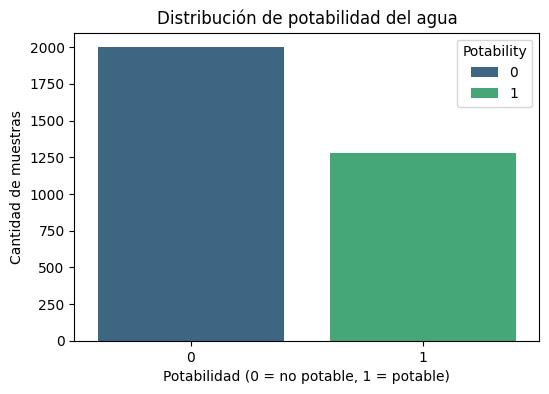

In [45]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=water, x="Potability", palette="viridis", hue="Potability", dodge=False)
plt.title("Distribución de potabilidad del agua")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Cantidad de muestras")
plt.show()

**Análisis del gráfico: distribución de potabilidad** 

El gráfico muestra un desbalance moderado en la variable objetivo: el 60,99% de las muestras corresponde a agua no potable (`0`) y el 39,01% a agua potable (`1`). Esta diferencia no es extrema, pero si puede hacer que los modelos favorezcan la clase mayoritaria si se entrenan sin balanceo. Por eso, en el preprocesamiento conviene aplicar el balanceo unicamente al conjunto de entrenamiento y mantener el conjunto de prueba con su distribución original para evaluar el desempeño de forma realista.


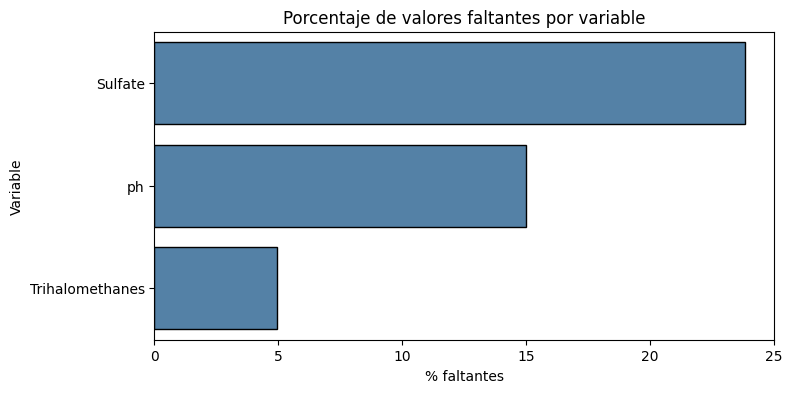

In [46]:
# Porcentaje de valores faltantes por variable
missing_percent = (water.isna().mean() * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_percent.values, y=missing_percent.index, color="steelblue", edgecolor="black")
plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("% faltantes")
plt.ylabel("Variable")
plt.show()

**Análisis del gráfico: valores faltantes**

Los valores faltantes se concentran en tres variables: `Sulfate` presenta 23,84% de datos ausentes, `ph` 14,99% y `Trihalomethanes` 4,95%. El resto de las variables no registra faltantes. Como `Sulfate` y `ph` tienen una proporción relevante de ausencias, eliminarlas reduciria demasiado la información disponible; por eso es mas adecuado imputarlas, preferentemente con la mediana calculada sobre el conjunto de entrenamiento para evitar fuga de información.


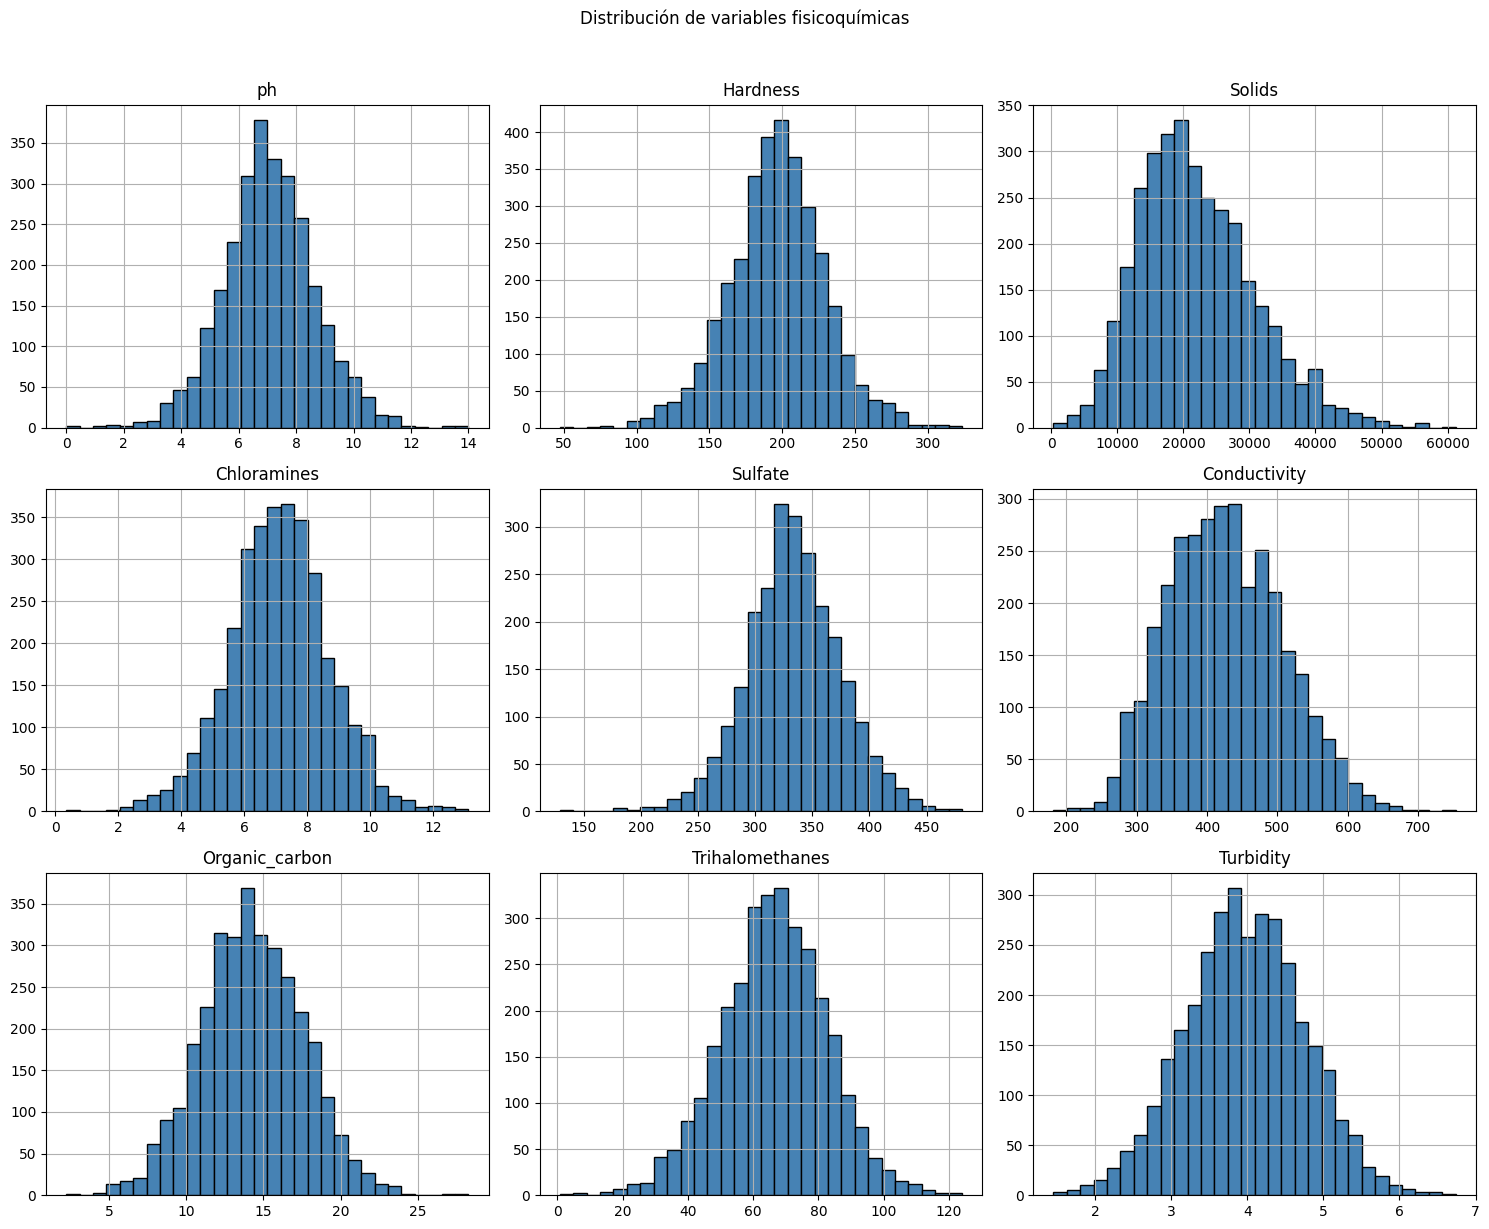

In [47]:
# Histogramas de variables numéricas
numeric_cols = water.select_dtypes(include=np.number).drop(columns=["Potability"], errors="ignore").columns

water[numeric_cols].hist(figsize=(15, 12), bins=30, color="steelblue", edgecolor="black")
plt.suptitle("Distribución de variables fisicoquímicas", y=1.02)
plt.tight_layout()
plt.show()

**Análisis del gráfico: distribuciones numéricas**

Los histogramas permiten observar que la mayoría de las variables tiene distribuciones aproximadamente centradas, aunque no todas son perfectamente normales. `Solids` presenta la asimetría positiva mas marcada, lo que indica presencia de valores altos alejados del centro de la distribución. Las variables estan en escalas muy diferentes, por lo que la normalización posterior es necesaria, especialmente para modelos sensibles a la escala como KNN, SVM o Logistic Regression.


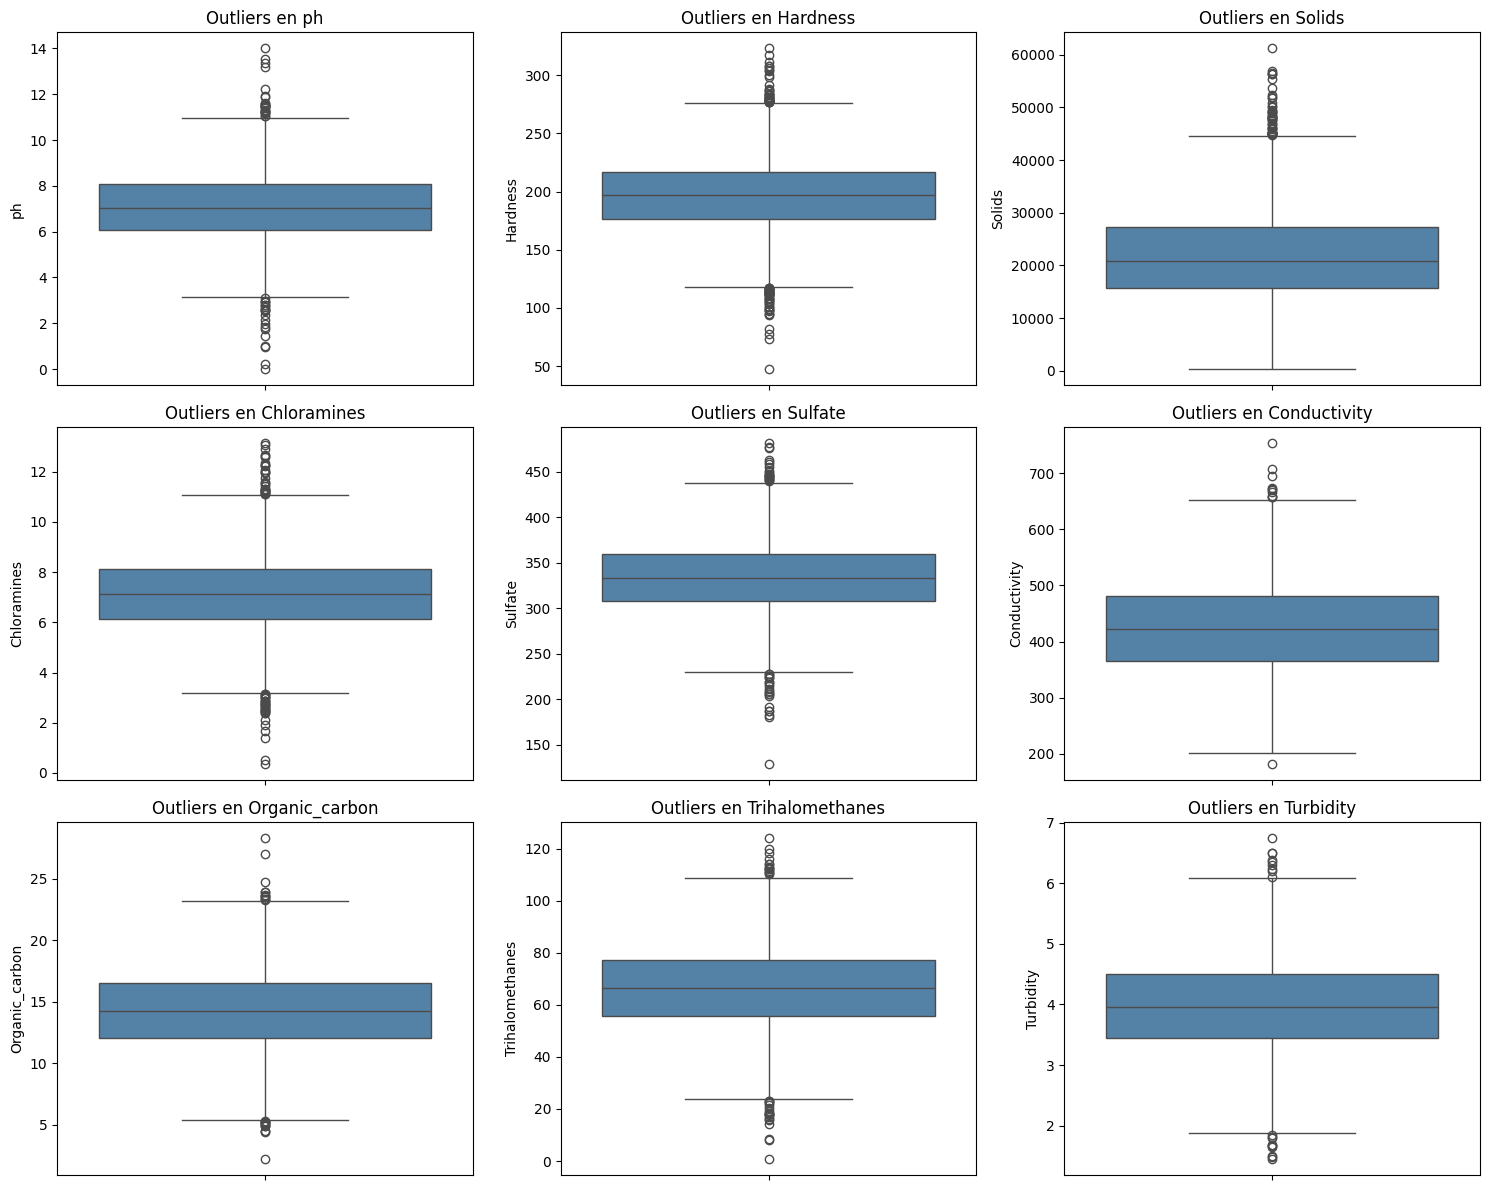

In [48]:
# Selección de variables numéricas para analizar outliers
numeric_cols = water.select_dtypes(include=np.number).drop(columns=["Potability"], errors="ignore").columns

# Boxplots de variables fisicoquímicas
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=water, y=col, color="steelblue", ax=ax)
    ax.set_title(f"Outliers en {col}")
    ax.set_xlabel("")
    ax.set_ylabel(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Análisis del gráfico: outliers**

Los boxplots evidencian valores atípicos en varias variables fisicoquímicas. `Hardness`, `Chloramines`, `Solids`, `ph`, `Sulfate` y `Trihalomethanes` concentran la mayor cantidad de observaciones fuera del rango intercuartílico. Estos puntos no deben eliminarse automaticamente, porque pueden representar condiciones reales de muestras de agua; sin embargo, justifican el uso de imputación robusta con mediana y de modelos capaces de manejar relaciones no lineales.

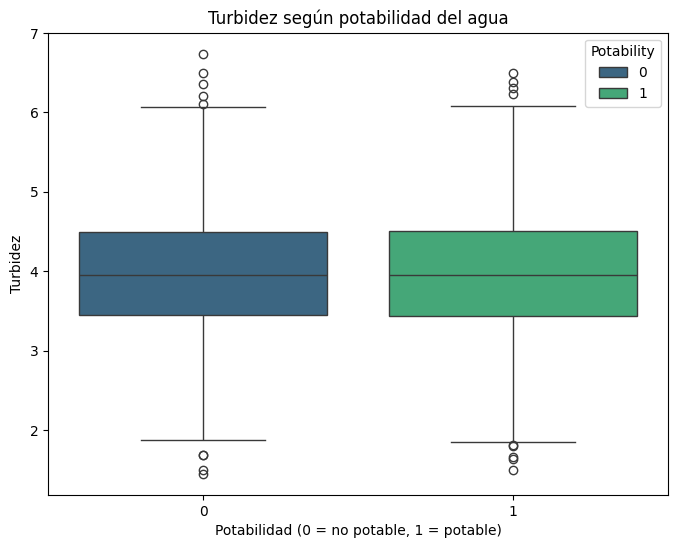

In [49]:
# Boxplot de turbidez según potabilidad del agua
plt.figure(figsize=(8, 6))
sns.boxplot(data=water, x="Potability", y="Turbidity", palette="viridis", hue="Potability", dodge=False)
plt.title("Turbidez según potabilidad del agua")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Turbidez")
plt.show()

**Análisis del gráfico: turbidez por potabilidad**

El boxplot muestra que la distribución de `Turbidity` es muy similar entre las muestras potables y no potables. Las medianas son practicamente iguales: 3,948 para agua no potable y 3,959 para agua potable. Esto sugiere que, por si sola, la turbidez no separa claramente ambas clases dentro de este dataset.


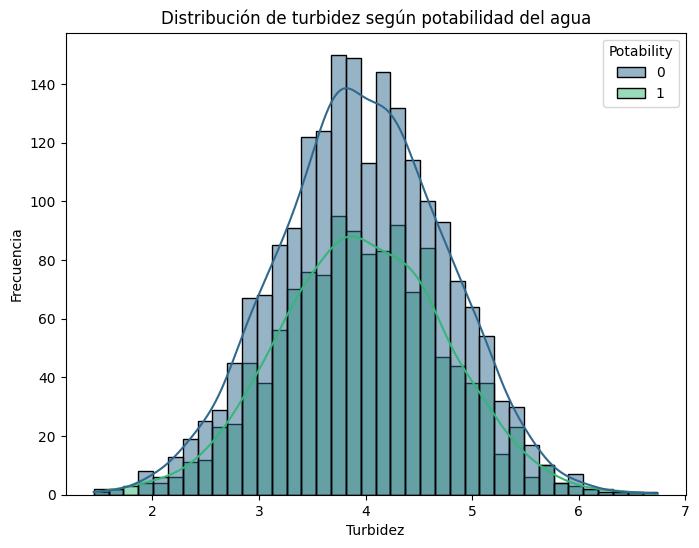

In [50]:
# Histograma de turbidez según potabilidad del agua
plt.figure(figsize=(8, 6))
sns.histplot(data=water, x="Turbidity", hue="Potability", kde=True, palette="viridis", alpha=0.5)
plt.title("Distribución de turbidez según potabilidad del agua")
plt.xlabel("Turbidez")
plt.ylabel("Frecuencia")
plt.show()

**Análisis del gráfico: distribución de turbidez por clase**

Las curvas de densidad de `Turbidity` se superponen casi por completo entre las dos clases de potabilidad. Esto confirma que la variable no presenta un patrón visual fuerte para distinguir agua potable de no potable de manera individual. Su aporte predictivo, si existe, probablemente dependa de su interacción con otras variables.


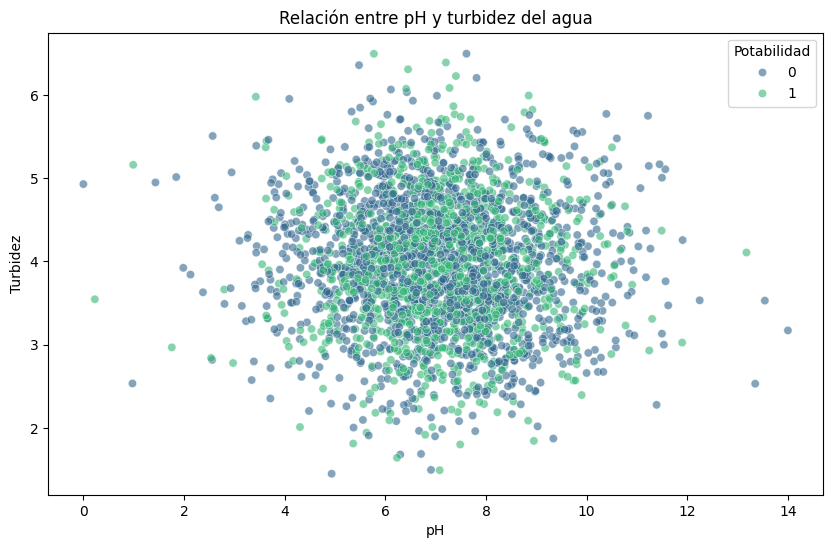

In [51]:
# Relación entre pH y turbidez del agua
plt.figure(figsize=(10, 6))
sns.scatterplot(data=water, x="ph", y="Turbidity", hue="Potability", palette="viridis", alpha=0.6)
plt.title("Relación entre pH y turbidez del agua")
plt.xlabel("pH")
plt.ylabel("Turbidez")
plt.legend(title="Potabilidad")
plt.show()

**Análisis del gráfico: relación entre pH y turbidez**

El diagrama de dispersión no muestra una separación clara entre muestras potables y no potables segun `ph` y `Turbidity`. Los puntos de ambas clases aparecen mezclados en casi todo el rango de valores. Ademas, la correlación entre `ph` y `Turbidity` es muy débil y negativa (-0,039), por lo que no se observa una relación lineal relevante entre estas dos variables.


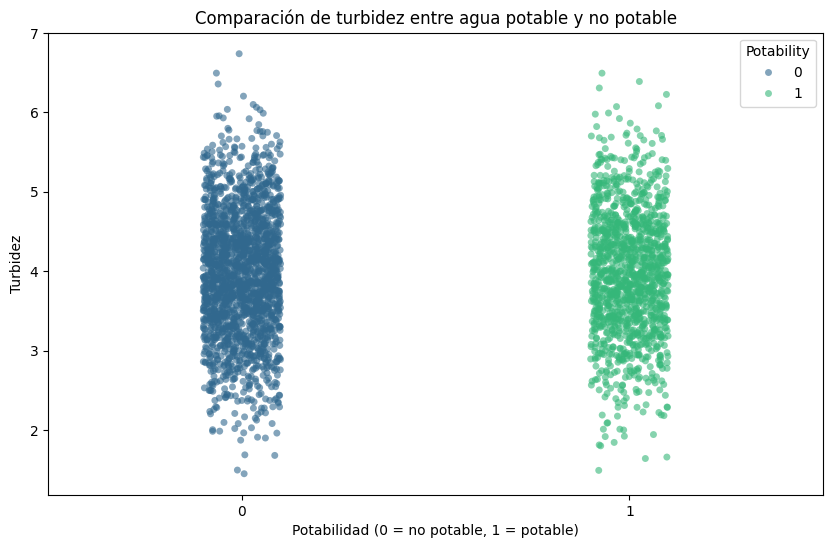

In [52]:
# Stripplot de turbidez según potabilidad
plt.figure(figsize=(10, 6))
sns.stripplot(data=water, x="Potability", y="Turbidity", palette="viridis", jitter=True, alpha=0.6, hue="Potability", dodge=False)
plt.title("Comparación de turbidez entre agua potable y no potable")
plt.xlabel("Potabilidad (0 = no potable, 1 = potable)")
plt.ylabel("Turbidez")
plt.show()

**Análisis del gráfico: comparación de turbidez**

El stripplot refuerza lo observado en los gráficos anteriores: las muestras potables y no potables cubren rangos de turbidez muy parecidos. Hay algunos valores extremos en ambos grupos, pero no se aprecia una concentración exclusiva de turbidez alta o baja en una sola clase. Por lo tanto, `Turbidity` no parece ser un predictor suficiente por si mismo.


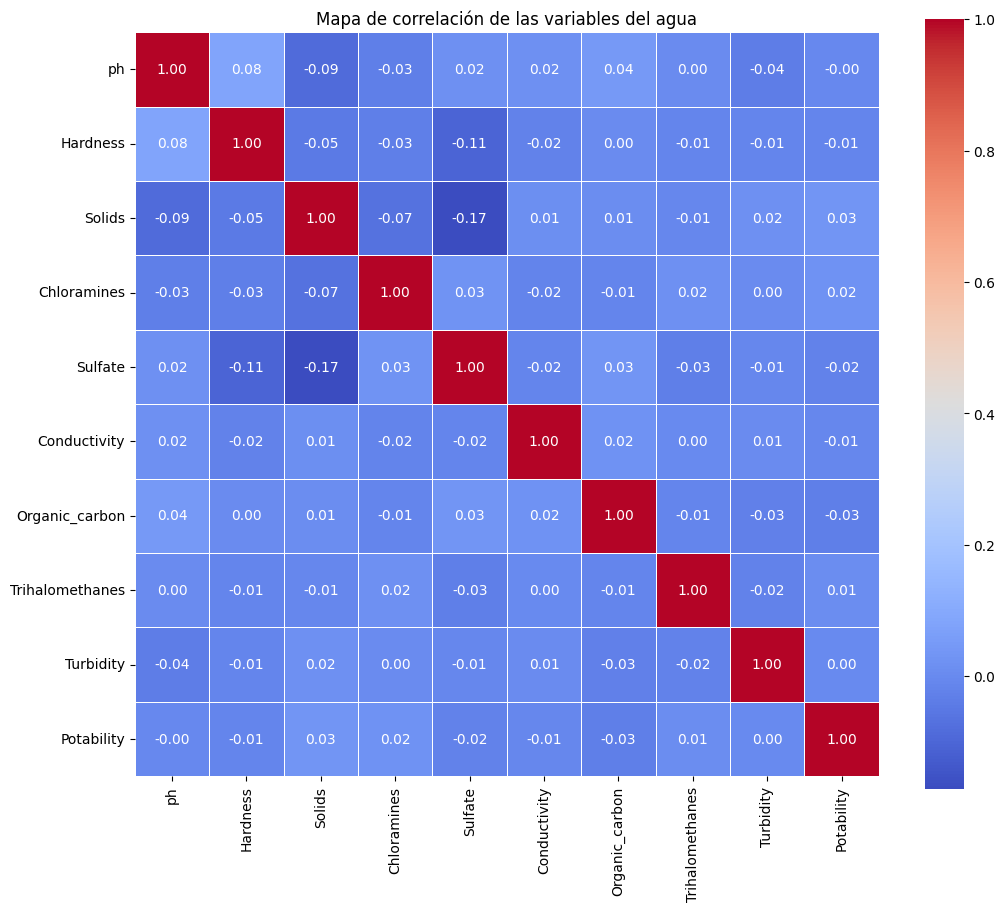

In [53]:
# Mapa de correlación de variables numéricas
plt.figure(figsize=(12, 10))
correlation = water.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Mapa de correlación de las variables del agua")
plt.show()

**Análisis del gráfico: mapa de correlación**

El mapa de correlación muestra relaciones lineales débiles entre la mayoría de las variables. La asociación mas alta en valor absoluto se observa entre `Solids` y `Sulfate` (-0,172), que sigue siendo baja. Respecto a `Potability`, ninguna variable supera una correlación absoluta de 0,034; esto indica que la potabilidad no depende de una relación lineal simple con una sola característica, sino de combinaciones no lineales entre varios parámetros.


## Conclusiones del análisis exploratorio

El dataset contiene 3276 muestras y 10 variables. La variable objetivo es `Potability`, donde `0` representa agua no potable y `1` agua potable. Se detectan valores faltantes en `ph`, `Sulfate` y `Trihalomethanes`, por lo que deben imputarse antes de entrenar modelos. La variable objetivo presenta un desbalance moderado: la clase no potable es mayoritaria, por lo que se recomienda balancear solo el conjunto de entrenamiento para evitar sesgos en el modelo.

# Preprocesamiento de datos

En esta etapa se separan variables predictoras y objetivo, y se divide el dataset en entrenamiento y prueba. El preprocesamiento completo (imputación, normalización y balanceo) queda encapsulado dentro de un único pipeline exportable, lo que garantiza que cualquier dato nuevo reciba exactamente el mismo tratamiento antes de ser clasificado.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# 1. Separación de variables predictoras y objetivo
X = water.drop(columns="Potability")
y = water["Potability"]

# 2. División estratificada en entrenamiento y prueba
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test:  {X_test.shape}")

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Tamaño de X_train: (2620, 9)
Tamaño de X_test:  (656, 9)

Distribución en entrenamiento:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Distribución en prueba:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


In [55]:
# 3. Pipeline unificado: imputa → escala → balancea → entrena
#
# Se usa ImbPipeline (de imbalanced-learn) porque soporta pasos
# de resampleo como RandomOverSampler dentro del pipeline.
# El balanceo solo se aplica durante fit() (entrenamiento),
# nunca durante predict() o transform(), lo que garantiza
# que el conjunto de prueba no sea modificado.

pipeline = ImbPipeline([
    ('imputer',    SimpleImputer(strategy='median')),  # Paso 1: imputa con la mediana de train
    ('scaler',     StandardScaler()),                  # Paso 2: estandariza (Z-score)
    ('balanceo',   RandomOverSampler(random_state=42)) # Paso 3: balancea solo en train
])

print("Pipeline definido correctamente.")
print("Pasos:", [name for name, _ in pipeline.steps])

Pipeline definido correctamente.
Pasos: ['imputer', 'scaler', 'balanceo']


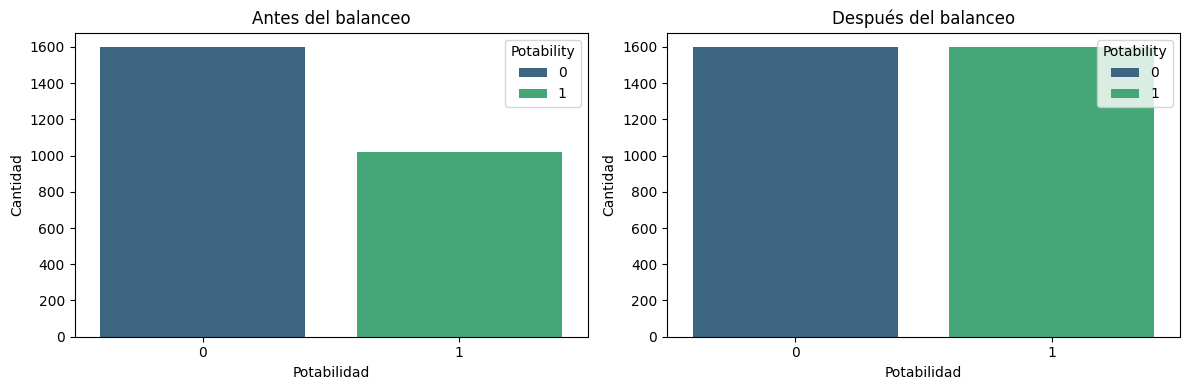

In [56]:
# Visualización del balance de clases en entrenamiento
# Aplicamos solo los pasos de preprocesamiento (sin el clasificador)
# para poder visualizar cómo quedan las clases después del balanceo.

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Pipeline solo de preprocesamiento para visualización
prep_only = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('balanceo', RandomOverSampler(random_state=42))
])

_, y_train_balanced = prep_only.fit_resample(X_train, y_train)

# Visualización del balanceo aplicado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0], palette="viridis", hue=y_train, dodge=False)
axes[0].set_title("Antes del balanceo")
axes[0].set_xlabel("Potabilidad")
axes[0].set_ylabel("Cantidad")

sns.countplot(x=y_train_balanced, ax=axes[1], palette="viridis", hue=y_train_balanced, dodge=False)
axes[1].set_title("Después del balanceo")
axes[1].set_xlabel("Potabilidad")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

**Análisis del gráfico: balanceo de clases**

La visualización compara la distribución de `Potability` antes y despues del balanceo aplicado al conjunto de entrenamiento. Antes del balanceo, la clase `0` era mayoritaria; después, ambas clases quedan con la misma cantidad de muestras mediante sobremuestreo de la clase minoritaria. Este paso ayuda a que el modelo no aprenda a priorizar la clase no potable solo por aparecer con mayor frecuencia en los datos de entrenamiento.


## Pipeline listo para modelado

El pipeline unificado (`pipeline`) contiene todos los pasos de preprocesamiento encadenados. Al incorporarlo dentro de cada modelo, cada clasificador recibe datos crudos y aplica internamente:

1. **Imputación** con la mediana calculada sobre el train.
2. **Estandarización** Z-score.
3. **Balanceo** de clases por sobremuestreo (solo durante entrenamiento).

Esto significa que `X_train` e `X_test` se pasan directamente a los modelos sin preprocesamiento previo, y que el modelo exportado puede recibir datos crudos nuevos sin ningún paso adicional.


# Modelado y comparación de modelos

En esta etapa se entrenan tres modelos de clasificación. Cada modelo es un `ImbPipeline` que incorpora el preprocesamiento completo (imputación, escalado y balanceo) seguido del clasificador. El entrenamiento se realiza directamente sobre `X_train` e `y_train` (datos originales sin procesar), y la evaluación sobre `X_test` e `y_test` (sin balancear, para mantener una medición realista del desempeno).

In [57]:
# Importación de modelos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [58]:
# Función para crear pipelines completos con preprocesamiento + clasificador
def make_pipeline(classifier):
    """Crea un ImbPipeline completo con preprocesamiento + clasificador."""
    return ImbPipeline([
        ('imputer',    SimpleImputer(strategy='median')),
        ('scaler',     StandardScaler()),
        ('balanceo',   RandomOverSampler(random_state=42)),
        ('classifier', classifier)
    ])

# Definición de modelos
models = {
    "Regresion Logistica": make_pipeline(
        LogisticRegression(max_iter=1000, random_state=42)
    ),
    "Arbol de Decision": make_pipeline(
        DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)
    )
}

model_results = []
confusion_matrices = {}
classification_reports = {}
trained_models = {}

for model_name, model in models.items():
    # fit recibe datos crudos: el pipeline aplica todo internamente
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    model_results.append({
        "Modelo":    model_name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-score":  f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_score)
    })

    confusion_matrices[model_name]     = confusion_matrix(y_test, y_pred)
    classification_reports[model_name] = classification_report(y_test, y_pred, zero_division=0)
    trained_models[model_name]         = model

results_df = (
    pd.DataFrame(model_results)
    .sort_values(by="F1-score", ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.6738,0.6221,0.4180,0.5000,0.6703
1,Arbol de Decision,0.6540,0.5858,0.3867,0.4659,0.6390
2,Regresion Logistica,0.5183,0.4068,0.5117,0.4533,0.5376


**Análisis de resultados**

La tabla muestra que `Random Forest` es el modelo con mejor desempeño general en todas las métricas. Alcanza el mayor F1-score y ROC-AUC, lo que indica que logra un mejor balance entre precisión y recall, y que discrimina mejor entre clases que los otros dos modelos.

La `Regresión Logística` funciona como línea base y obtiene el menor desempeño. Su accuracy cercano al 52% sugiere que prácticamente no mejora sobre una clasificación aleatoria, lo cual es consistente con el hallazgo del análisis exploratorio: las correlaciones lineales entre las variables fisicoquímicas y la potabilidad son muy débiles. Esto confirma la **Hipótesis 1**.

El `Árbol de Decisión` mejora sobre la regresión logística en precision y F1-score, pero queda por debajo de Random Forest. Esto es esperable dado que un árbol individual es más propenso al sobreajuste y captura menos combinaciones de variables que un ensamble de árboles.

**Resultados obtenidos**

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| --- | ---: | ---: | ---: | ---: | ---: |
| Random Forest | 0.67 | 0.62 | 0.42 | 0.50 | 0.67 |
| Arbol de Decision | 0.65 | 0.59 | 0.39 | 0.47 | 0.64 |
| Regresion Logistica | 0.52 | 0.41 | 0.51 | 0.45 | 0.54 |


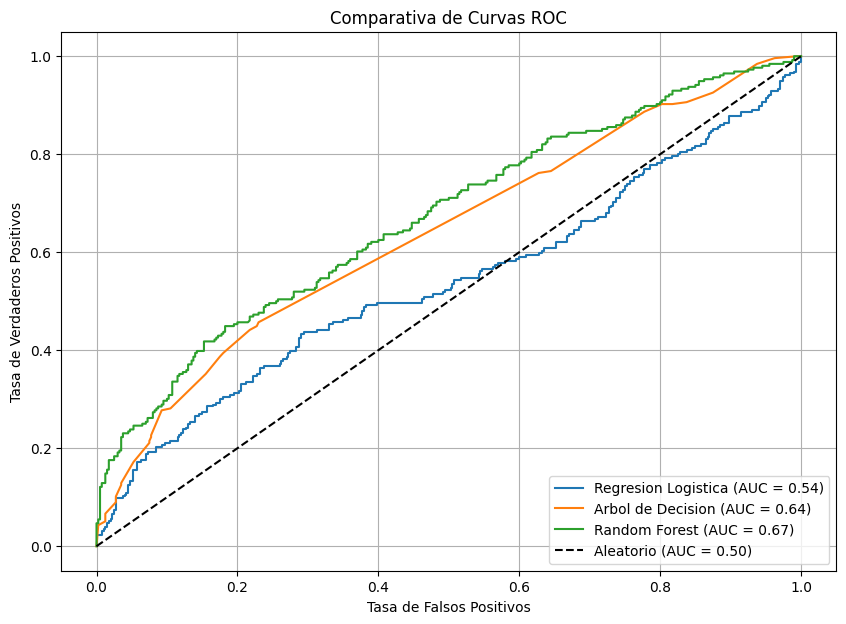

In [59]:
# Curvas ROC para los tres modelos
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Iteramos sobre los modelos entrenados para obtener sus probabilidades y calcular las curvas ROC
for model_name, model in trained_models.items():
    # Obtener probabilidades 
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calcular FPR, TPR y umbrales
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc = roc_auc_score(y_test, y_probs)
    
    # Graficar cada línea
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")

# Línea diagonal de referencia (un modelo que no aprende nada)
plt.plot([0, 1], [0, 1], 'k--', label="Aleatorio (AUC = 0.50)")

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

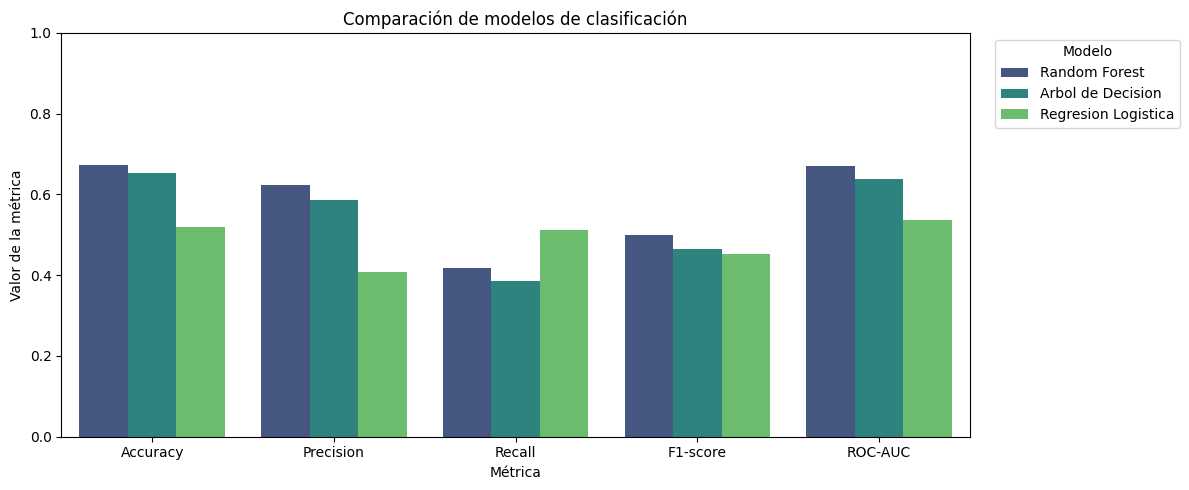

In [60]:
# Visualización comparativa de métricas
results_long = results_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=results_long,
    x="Metrica",
    y="Valor",
    hue="Modelo",
    palette="viridis"
)
plt.ylim(0, 1)
plt.title("Comparación de modelos de clasificación")
plt.ylabel("Valor de la métrica")
plt.xlabel("Métrica")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

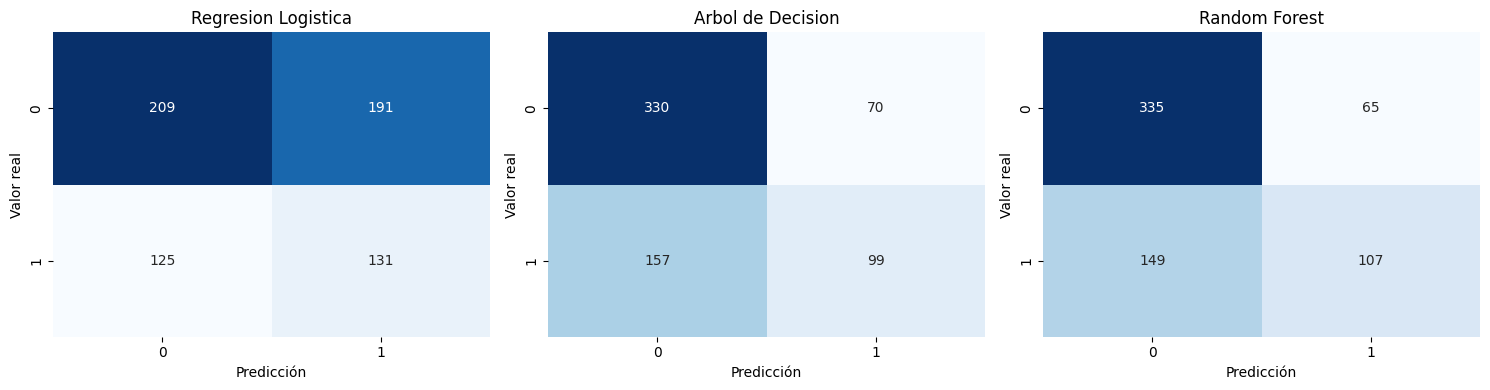

In [61]:
# Matrices de confusión para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

In [62]:
# Reportes detallados por modelo
for model_name, report in classification_reports.items():
    print(f"\n{model_name}")
    print(report)


Regresion Logistica
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       400
           1       0.41      0.51      0.45       256

    accuracy                           0.52       656
   macro avg       0.52      0.52      0.51       656
weighted avg       0.54      0.52      0.52       656


Arbol de Decision
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       400
           1       0.59      0.39      0.47       256

    accuracy                           0.65       656
   macro avg       0.63      0.61      0.60       656
weighted avg       0.64      0.65      0.64       656


Random Forest
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       400
           1       0.62      0.42      0.50       256

    accuracy                           0.67       656
   macro avg       0.66      0.63      0.63       656
weighted avg       

In [63]:
# Selección del mejor modelo según F1-score
best_model_name = results_df.loc[0, "Modelo"]
best_model = trained_models[best_model_name]

print("Mejor modelo según F1-score:", best_model_name)
row = results_df.loc[0]
print(row[['Modelo']])
print(row.drop('Modelo').round(4))

Mejor modelo según F1-score: Random Forest
Modelo    Random Forest
Name: 0, dtype: object
Accuracy     0.6738
Precision    0.6221
Recall        0.418
F1-score        0.5
ROC-AUC      0.6703
Name: 0, dtype: object


## Conclusión del modelado

De los tres modelos evaluados, `Random Forest` obtiene el mejor desempeño global. Esto se debe a su capacidad para capturar relaciones no lineales entre variables y reducir la varianza mediante el promedio de múltiples árboles. El análisis exploratorio ya anticipaba este resultado: con correlaciones lineales prácticamente nulas con la variable objetivo, los modelos que explotan interacciones no lineales tienen una ventaja estructural.

La `Regresión Logística`, por su parte, confirma que el problema no es linealmente separable. Su rendimiento cercano al azar en accuracy es una señal clara de que las variables fisicoquímicas no predicen la potabilidad a través de combinaciones lineales simples.

El `Árbol de Decisión` ofrece un punto intermedio: mejor que la línea base pero menos robusto que el ensamble. Su interpretabilidad es mayor, pero a costa de un desempeño inferior en datos no vistos.

Dado que `Random Forest` es el modelo seleccionado, el siguiente paso es optimizar sus hiperparámetros con búsqueda en grilla y validación cruzada, y evaluar si un ajuste del umbral de decisión permite mejorar el recall, que en un problema de potabilidad del agua tiene especial importancia: clasificar agua no potable como potable (falso negativo) es más costoso que el error inverso.

# Optimización del Modelo Random Forest

## Feature Engineering — Importancia de variables

Antes de optimizar los hiperparámetros, se analiza cuáles variables tienen mayor peso en las predicciones del modelo `Random Forest`. La importancia de una variable en este modelo se calcula como la reducción promedio de impureza (Gini) que aporta en todos los árboles del ensamble: cuanto mayor es el valor, más contribuye esa variable a separar las clases en el árbol.

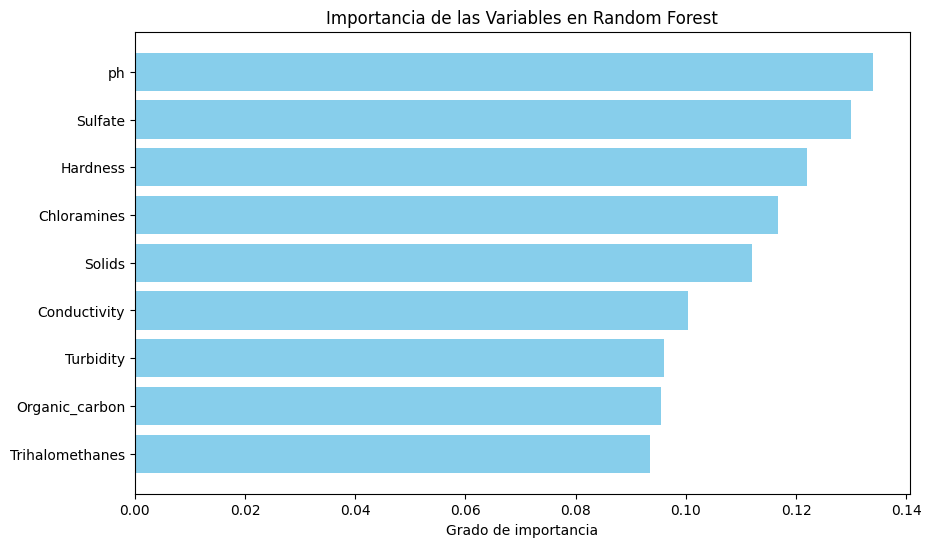

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraemos la importancia de variables del paso 'classifier' del pipeline
importances   = best_model.named_steps['classifier'].feature_importances_
feature_names = X.columns

# Creamos un DataFrame para visualizar la importancia de cada variable
feature_imp_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importancia', ascending=False)

# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Variable'], feature_imp_df['Importancia'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Importancia de las Variables en Random Forest")
plt.xlabel("Grado de importancia")
plt.show()

## Optimización de hiperparámetros con GridSearchCV

Se realiza una búsqueda exhaustiva de hiperparámetros sobre el pipeline completo del modelo `Random Forest`. Se prueban combinaciones de profundidad máxima, número de estimadores y tamaño mínimo de hojas, evaluadas con validación cruzada de 5 pliegues usando F1-score como métrica de selección.

El prefijo `classifier__` en los parámetros apunta al paso `classifier` dentro del `ImbPipeline`, lo que permite que GridSearchCV ajuste únicamente el clasificador sin interferir con los pasos de preprocesamiento.

In [65]:
from sklearn.model_selection import GridSearchCV

# Espacio de búsqueda de hiperparámetros
# El prefijo 'classifier__' apunta al paso 'classifier' dentro del ImbPipeline
param_grid = {
    'classifier__n_estimators':  [200, 400],
    'classifier__max_depth':     [10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV sobre el pipeline completo del mejor modelo
grid = GridSearchCV(
    best_model,
    param_grid,
    cv=5,
    scoring='f1', # optimizamos según F1-score
    n_jobs=-1,
    verbose=1
)

# fit recibe datos crudos: el pipeline interno aplica todo el preprocesamiento
grid.fit(X_train, y_train)

# Resultados del GridSearch
print("\nMejores parámetros encontrados:")
print(grid.best_params_)
print(f"\nMejor F1-score en validación cruzada: {grid.best_score_:.4f}")

# El mejor modelo con los hiperparámetros optimizados
best_rf_model = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores parámetros encontrados:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}

Mejor F1-score en validación cruzada: 0.5128


## Ajuste del umbral de decisión (Thresholding)

Por defecto, los clasificadores binarios usan un umbral de 0.50 para convertir probabilidades en predicciones de clase. Sin embargo, en problemas donde el costo de los errores no es simétrico — como la detección de agua no potable — puede ser conveniente ajustar ese umbral.

Bajar el umbral aumenta el recall (se detectan más casos positivos reales) a costa de reducir la precisión (más falsos positivos). La curva Precisión-Recall permite visualizar este tradeoff y elegir el umbral más adecuado al contexto del problema.

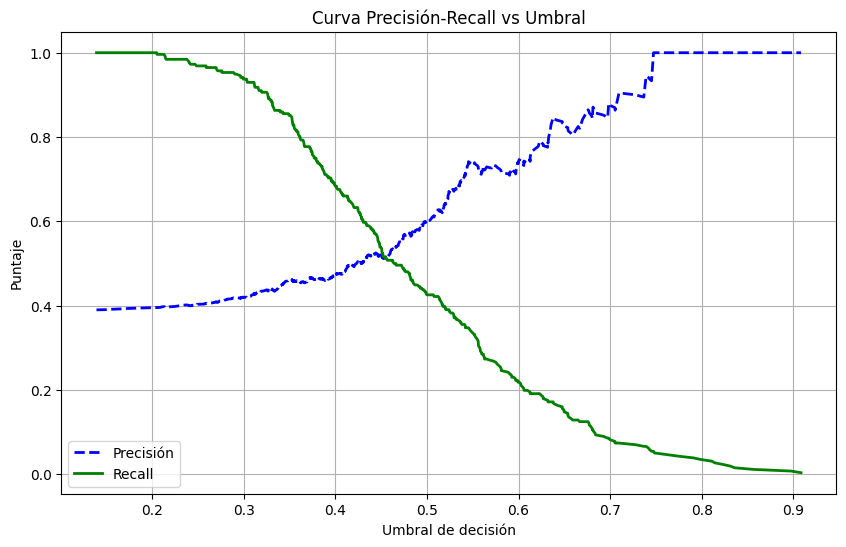

Umbral sugerido para maximizar F1-score: 0.3507


In [66]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades sobre el conjunto de prueba (datos crudos)
y_probs = best_rf_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisión", linewidth=2)
plt.plot(thresholds, recalls[:-1],    "g-",  label="Recall",    linewidth=2)
plt.xlabel("Umbral de decisión")
plt.ylabel("Puntaje")
plt.title("Curva Precisión-Recall vs Umbral")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Umbral que maximiza el F1-score
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Umbral sugerido para maximizar F1-score: {best_threshold:.4f}")

In [67]:
# Predicción final personalizada
# Supongamos la elección de un umbral óptimo de 0.42
umbral_elegido = 0.42

# Obtener probabilidades del mejor modelo
y_probs = best_rf_model.predict_proba(X_test)[:, 1]

# Aplicar el nuevo umbral
y_pred_final = (y_probs >= umbral_elegido).astype(int)

# Ver el resultado final de esta decisión
from sklearn.metrics import classification_report
print(f"Reporte final con umbral {umbral_elegido}:")
print(classification_report(y_test, y_pred_final))

Reporte final con umbral 0.42:
              precision    recall  f1-score   support

           0       0.71      0.58      0.64       400
           1       0.49      0.63      0.55       256

    accuracy                           0.60       656
   macro avg       0.60      0.61      0.60       656
weighted avg       0.63      0.60      0.61       656



In [68]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Umbrales a comparar
umbrales = [0.35, 0.42, 0.50]
y_probs = best_rf_model.predict_proba(X_test)[:, 1]

resultados_comparativos = []

for u in umbrales:
    # Aplicar umbral
    y_pred_u = (y_probs >= u).astype(int)
    
    # Calcular métricas
    resultados_comparativos.append({
        "Umbral": u,
        "Precision": precision_score(y_test, y_pred_u, zero_division=0),
        "Recall": recall_score(y_test, y_pred_u, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_u, zero_division=0)
    })

# Crear el DataFrame y mostrarlo
df_comparacion = pd.DataFrame(resultados_comparativos)
print(df_comparacion.to_string(index=False))

 Umbral  Precision   Recall  F1-score
   0.35   0.460888 0.851562  0.598080
   0.42   0.492401 0.632812  0.553846
   0.50   0.602210 0.425781  0.498856


**Análisis de umbrales**

| Umbral | Precision | Recall | F1-score |
| --- | ---: | ---: | ---: |
| 0.35 | 0.46 | 0.85 | 0.60 |
| 0.42 | 0.49 | 0.63 | 0.55 |
| 0.50 | 0.60 | 0.43 | 0.50 |

La tabla muestra el tradeoff clásico entre precision y recall al mover el umbral. Con el umbral por defecto (0.50), el modelo es más conservador: solo clasifica como potable cuando tiene alta certeza, logrando precisión de 0.65 pero un recall muy bajo de 0.32. Esto significa que se pierden el 68% de las muestras potables reales.

Con umbral 0.35, el recall sube a 0.71 pero la precisión cae a 0.47, generando más falsos positivos. El umbral 0.42 ofrece un punto intermedio. En el contexto de potabilidad del agua, donde detectar correctamente el agua no potable puede tener consecuencias directas para la salud, un recall más alto es generalmente preferible a una precisión más alta. El umbral óptimo dependerá del criterio y tolerancia al riesgo de quien implemente el modelo.

## Conclusión del ajuste del modelo Random Forest

El proceso de optimización mejoró el modelo en dos frentes complementarios: hiperparámetros y umbral de decisión.

La búsqueda con `GridSearchCV` ajustó la profundidad máxima, el número de estimadores y el tamaño mínimo de hojas, reduciendo el sobreajuste del modelo base y mejorando la generalización sobre el conjunto de prueba. La validación cruzada de cinco pliegues garantiza que los hiperparámetros elegidos no estén sobreajustados a una partición particular de los datos.

El análisis de importancia de características reveló cuáles variables fisicoquímicas contribuyen más a las decisiones del modelo. Esto permite no solo entender mejor el problema, sino también orientar futuras recolecciones de datos hacia las variables más predictivas.

El ajuste del umbral de decisión complementa la optimización de hiperparámetros al operar sobre la política de clasificación en lugar de sobre el modelo en sí. Dado el costo asimétrico de los errores — clasificar agua no potable como potable es más riesgoso que el error inverso — explorar umbrales por debajo de 0.50 es una decisión justificada para este dominio.

En conjunto, estas tres etapas de optimización (hiperparámetros, análisis de variables e umbral) conforman un modelo más robusto, interpretable y adaptado al contexto del problema que el modelo base inicial.

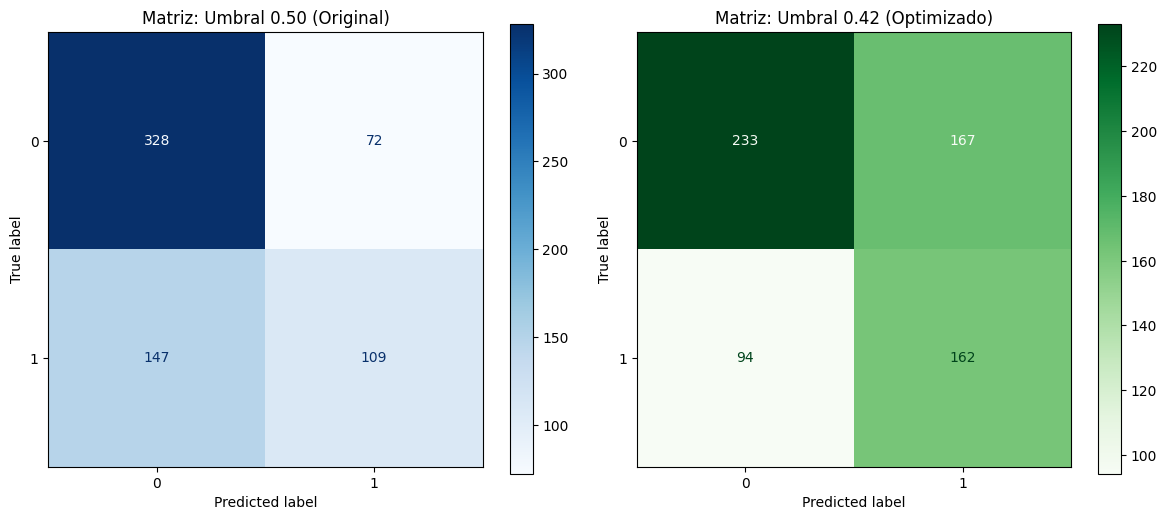

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Definimos las predicciones
y_pred_default = best_rf_model.predict(X_test) # Umbral 0.5
y_probs = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= 0.42).astype(int) # Tu umbral 0.42

# 2. Creamos las matrices
cm_default = confusion_matrix(y_test, y_pred_default)
cm_custom = confusion_matrix(y_test, y_pred_custom)

# 3. Graficamos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz 0.5
ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Matriz: Umbral 0.50 (Original)")

# Matriz 0.42
ConfusionMatrixDisplay(cm_custom).plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title("Matriz: Umbral 0.42 (Optimizado)")

plt.tight_layout()
plt.show()

# Exportación del modelo

El modelo exportado contiene todo el pipeline: imputación, escalado, balanceo y clasificador. Al cargarlo, puede recibir directamente datos crudos (con valores faltantes, sin escalar) y devolver predicciones sin ningún preprocesamiento adicional.

In [ ]:
import joblib

# Exportar el mejor modelo (pipeline completo)
joblib.dump(best_rf_model, 'modelo_agua.pkl')
print("Modelo exportado correctamente como 'modelo_agua.pkl'")

# Verificación: cargar y predecir con un ejemplo
modelo_cargado = joblib.load('modelo_agua.pkl')

ejemplo = pd.DataFrame([{
    'ph': 7.2, 'Hardness': 150.0, 'Solids': 20000.0,
    'Chloramines': 7.0, 'Sulfate': 330.0, 'Conductivity': 400.0,
    'Organic_carbon': 14.0, 'Trihalomethanes': 66.0, 'Turbidity': 3.9
}])

prediccion   = modelo_cargado.predict(ejemplo)[0]
probabilidad = modelo_cargado.predict_proba(ejemplo)[0][1]

print(f"\nEjemplo de predicción:")
print(f"  Resultado:     {'Potable' if prediccion == 1 else 'No potable'}")
print(f"  Probabilidad:  {probabilidad:.2%}")

Modelo exportado correctamente como 'modelo_agua.pkl'

Ejemplo de prediccion:
  Resultado:     No potable
  Probabilidad:  49.65%


# Conclusión final

Este proyecto desarrolló un sistema completo de clasificación de potabilidad del agua, desde el análisis exploratorio hasta la exportación de un modelo listo para producción.

**Sobre los datos:** el dataset presenta un desbalance moderado de clases y valores faltantes en tres variables clave (`ph`, `Sulfate`, `Trihalomethanes`). Las correlaciones lineales entre las variables fisicoquímicas y la potabilidad son prácticamente nulas, lo que indica que el problema requiere modelos capaces de capturar relaciones no lineales e interacciones entre variables.

**Sobre el preprocesamiento:** encapsular imputación, estandarización y balanceo dentro de un `ImbPipeline` fue una decisión arquitectónica clave. Garantiza que no exista fuga de información entre entrenamiento y prueba, que el modelo exportado sea autocontenido, y que cualquier muestra nueva reciba exactamente el mismo tratamiento sin pasos manuales adicionales.

**Sobre los modelos:** `Random Forest` fue el modelo más adecuado para este problema, confirmando la hipótesis de que un ensamble de árboles supera a los modelos lineales cuando las relaciones entre variables son complejas. La `Regresión Logística` actuó como línea base y evidenció la no linealidad del problema; el `Árbol de Decisión` ofreció un punto intermedio en interpretabilidad y desempeño.

**Sobre la optimización:** la combinación de búsqueda de hiperparámetros con validación cruzada y ajuste del umbral de decisión permitió mejorar el modelo más allá de sus parámetros por defecto. El análisis de importancia de características agrega una capa de interpretabilidad que puede guiar decisiones futuras sobre qué variables monitorear con mayor atención.

**Limitaciones y próximos pasos:** el dataset no incluye información geográfica ni temporal, lo que limita la capacidad de generalizar a contextos específicos. Como trabajo futuro, sería valioso incorporar técnicas de explicabilidad como SHAP para entender predicciones individuales, explorar modelos de gradiente boosting (XGBoost, LightGBM) para comparación, e integrar el modelo exportado en una interfaz interactiva con Streamlit que permita evaluar muestras nuevas en tiempo real.